# Text mining społeczności muzycznych Reddita

Notebook przedstawia analizę NLP komentarzy pochodzących z wybranych subredditów muzycznych. Celem analizy jest porównanie języka, sentymentu oraz głównych tematów dyskusji w społecznościach skupionych wokół różnych gatunków muzycznych.

Analiza obejmuje trzy główne obszary: preprocessing tekstu, identyfikację charakterystycznych słów i fraz, analizę sentymentu oraz modelowanie tematów z wykorzystaniem LDA.

## 1. Przygotowanie środowiska

W tej części importowane są biblioteki, definiowane ścieżki zapisu wyników oraz ustawiany jest jednolity styl wizualizacji. Notebook zapisuje tabele do folderu `outputs/reports`, a wykresy do folderu `outputs/figures`.

In [4]:
from pathlib import Path
from collections import Counter
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

try:
    import spacy

    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    USE_SPACY = True
except Exception:
    nlp = None
    USE_SPACY = False

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"
CHECKPOINT_DIR = DATA_DIR / "checkpoints"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "processed" / "all_subreddits_clean.csv"

SUBREDDIT_LABELS = {
    "Metal": "Metal",
    "hiphopheads": "Hip-hop",
    "popheads": "Pop",
    "indieheads": "Indie",
}


def subreddit_display(name: str) -> str:
    return SUBREDDIT_LABELS.get(str(name), str(name))


print(f"Model jezykowy spaCy dostepny: {USE_SPACY}")

Model jezykowy spaCy dostepny: True


In [5]:
# Konfiguracja checkpointów (ułatwia wznowienie pracy po resecie kernela)
print(f"Katalog checkpointów: {CHECKPOINT_DIR.resolve()}")

Katalog checkpointów: C:\Users\jaswe\OneDrive\Dokumenty\GitHub\Reddit-Music-Community-Analysis\data\checkpoints


## 2. Wczytanie danych

Dane zawierają komentarze z wybranych subredditów muzycznych. W dalszej części notebooka zakładane jest, że podstawowymi kolumnami są co najmniej: `subreddit`, `body` oraz `author`.

In [4]:
df_raw = pd.read_csv(DATA_PATH)

required_columns = {"subreddit", "body", "author"}
missing_columns = required_columns - set(df_raw.columns)
if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

basic_info = pd.DataFrame({
    "metryka": ["liczba wierszy", "liczba kolumn", "liczba subredditów"],
    "wartość": [len(df_raw), df_raw.shape[1], df_raw["subreddit"].nunique()]
})

basic_info.to_csv(REPORTS_DIR / "text_mining_dataset_summary.csv", index=False)

display(basic_info)
display(df_raw.head())

,metryka,wartość
0,liczba wierszy,2492764
1,liczba kolumn,15
2,liczba subredditów,4


,comment_id,author,body,subreddit,score,created_utc,parent_id,link_id,controversiality,gilded,date,year,month,body_len,word_count
0,fk5omrz,Moron_on_Oxy-,Read that Baby Keem had a few tweets complaini...,hiphopheads,2,1583884815,t3_fglr4p,t3_fglr4p,0,0,2020-03-11 00:00:15,2020,2020-03,141,20
1,fk5ono1,superchingonguey,Yeah I stumbled upon her about a year ago. She...,hiphopheads,2,1583884830,t1_fk5o56t,t3_fgnnun,0,0,2020-03-11 00:00:30,2020,2020-03,148,28
2,fk5osck,Aniceguy96,"For sure Billy has more energy, Ka puts me to ...",hiphopheads,1,1583884906,t1_fk5mi66,t3_fglr4p,0,0,2020-03-11 00:01:46,2020,2020-03,134,25
3,fk5oslg,Sushieatinbeast,Passion of the weiss is for the culture. I've ...,hiphopheads,20,1583884910,t3_fgihaz,t3_fgihaz,0,0,2020-03-11 00:01:50,2020,2020-03,83,15
4,fk5ourg,DocterJohnSmith,"Wifey Riddim, Swerve N Skid, The Lane, Naila, ...",hiphopheads,2,1583884946,t1_fk5o548,t3_fglr4p,0,0,2020-03-11 00:02:26,2020,2020-03,83,14


In [5]:
# Save df_raw checkpoint
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_raw_checkpoint_path = CHECKPOINT_DIR / "df_raw_checkpoint.pkl"
df_raw.to_pickle(df_raw_checkpoint_path)
print(f"Zapisano df_raw do: {df_raw_checkpoint_path}")
print(f"df_raw shape: {df_raw.shape}")

Zapisano df_raw do: ..\data\checkpoints\df_raw_checkpoint.pkl
df_raw shape: (2492764, 15)


In [6]:
# Load df_raw from checkpoint if available
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_raw_checkpoint_path = CHECKPOINT_DIR / "df_raw_checkpoint.pkl"
if df_raw_checkpoint_path.exists():
    df_raw = pd.read_pickle(df_raw_checkpoint_path)
    print(f"Wczytano df_raw z: {df_raw_checkpoint_path}")
    print(f"df_raw shape: {df_raw.shape}")
else:
    print(f"Brak checkpointu: {df_raw_checkpoint_path}")

Wczytano df_raw z: ..\data\checkpoints\df_raw_checkpoint.pkl
df_raw shape: (2492764, 15)


## 3. Opis przygotowania i oczyszczania danych tekstowych

Proces przygotowania danych został uporządkowany tak, aby wszystkie analizy opierały się na tym samym, wcześniej oczyszczonym zbiorze komentarzy. Wstępne czyszczenie danych, obejmujące usunięcie botów, kont technicznych oraz komentarzy niedostępnych, zostało wykonane już w notebooku EDA. Dzięki temu w tej części projektu możliwe było skupienie się wyłącznie na przygotowaniu tekstu do analiz języka naturalnego.

Kolejne etapy obejmowały:

1. zamianę tekstu na małe litery,
2. usunięcie adresów URL,
3. usunięcie znaków specjalnych oraz nadmiarowych spacji,
4. podział tekstu na tokeny,
5. usunięcie stopwords oraz dodatkowych słów o niskiej wartości analitycznej,
6. lematyzację z wykorzystaniem biblioteki spaCy, a w przypadku braku modelu językowego — stemming z użyciem `PorterStemmer`.

Dodatkowo zastosowano rozszerzoną listę słów wykluczanych, obejmującą często występujące pojęcia związane z muzyką i samą platformą Reddit, takie jak „music”, „song”, „album” czy „subreddit”. Pozwoliło to ograniczyć wpływ bardzo ogólnych słów na dalsze wyniki analiz.

Tak przygotowany zbiór danych został następnie wykorzystany w analizie TF-IDF, analizie sentymentu oraz modelowaniu tematów metodą LDA.

In [7]:
from tqdm import tqdm
import time

# przygotowanie tekstu do analiz NLP

base_stopwords = set(stopwords.words("english"))

extra_stopwords = {
    "like", "just", "get", "got", "one", "know", "think", "really", "would",
    "also", "even", "much", "still", "way", "good", "make", "people", "time",
    "music", "song", "songs", "album", "albums", "artist", "artists", "track", "tracks",
    "band", "bands", "https", "http", "www", "com", "reddit", "amp", "subreddit"
}

STOP_WORDS = base_stopwords | extra_stopwords
stemmer = PorterStemmer()


def log_step(message: str, start_time=None):
    now = time.strftime("%H:%M:%S")

    if start_time is None:
        print(f"[{now}] {message}")
    else:
        elapsed = time.time() - start_time
        print(f"[{now}] {message} | czas: {elapsed:.2f} s")


def remove_urls(text: str) -> str:
    return re.sub(r"http\S+|www\.\S+", " ", text)


def clean_text_basic(text: str) -> str:
    text = str(text).lower()
    text = remove_urls(text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_texts(texts: pd.Series) -> list[list[str]]:
    step_start = time.time()

    log_step("Czyszczenie tekstów przed tokenizacją...")

    cleaned_texts = (
        texts
        .fillna("")
        .astype(str)
        .map(clean_text_basic)
        .tolist()
    )

    log_step(
        f"Zakończono czyszczenie tekstów. Liczba tekstów: {len(cleaned_texts):,}",
        step_start
    )

    if USE_SPACY:
        log_step("Rozpoczynam preprocessing spaCy...")

        processed = []
        spacy_start = time.time()

        for doc in tqdm(
            nlp.pipe(cleaned_texts, batch_size=500),
            total=len(cleaned_texts),
            desc="spaCy preprocessing",
            unit="komentarz"
        ):
            tokens = [
                token.lemma_.lower()
                for token in doc
                if token.is_alpha
                and token.lemma_.lower() not in STOP_WORDS
                and len(token.lemma_) > 2
            ]

            processed.append(tokens)

        log_step("Zakończono preprocessing spaCy", spacy_start)

        return processed

    log_step("Rozpoczynam preprocessing NLTK...")

    processed = []
    nltk_start = time.time()

    for text in tqdm(
        cleaned_texts,
        total=len(cleaned_texts),
        desc="NLTK preprocessing",
        unit="komentarz"
    ):
        tokens = [
            stemmer.stem(token)
            for token in word_tokenize(text)
            if token.isalpha()
            and token not in STOP_WORDS
            and len(token) > 2
        ]

        processed.append(tokens)

    log_step("Zakończono preprocessing NLTK", nltk_start)

    return processed


def prepare_text_mining_dataset(df: pd.DataFrame) -> pd.DataFrame:
    total_start = time.time()

    log_step("Rozpoczynam przygotowanie danych do text mining...")
    log_step(f"Liczba rekordów wejściowych: {len(df):,}")

    filtered = df.copy()

    # Zabezpieczenie, gdyby notebook został uruchomiony na innym pliku niż oczyszczony.
    filtered["body"] = filtered["body"].fillna("").astype(str)
    filtered["author"] = filtered["author"].fillna("unknown").astype(str)

    safety_mask = (
        filtered["body"]
        .str.strip()
        .str.lower()
        .isin(["[deleted]", "[removed]", "deleted", "removed", ""])
    )

    if safety_mask.sum() > 0:
        log_step(f"Usunięto dodatkowe techniczne komentarze: {safety_mask.sum():,}")
        filtered = filtered.loc[~safety_mask].copy()

    step_start = time.time()

    filtered["clean_text"] = filtered["body"].map(clean_text_basic)

    log_step("Utworzono kolumnę clean_text", step_start)

    step_start = time.time()

    before_empty = len(filtered)
    filtered = filtered[filtered["clean_text"].str.len() > 0].copy()

    log_step(
        f"Usunięto puste clean_text: {before_empty - len(filtered):,}. Pozostało: {len(filtered):,}",
        step_start
    )

    step_start = time.time()

    log_step("Rozpoczynam tokenizację i lematyzację/stemming — to najdłuższy etap.")

    filtered["tokens"] = preprocess_texts(filtered["body"])

    log_step("Utworzono kolumnę tokens", step_start)

    step_start = time.time()

    filtered["processed_text"] = filtered["tokens"].map(lambda tokens: " ".join(tokens))
    filtered["token_count"] = filtered["tokens"].map(len)

    log_step("Utworzono kolumny processed_text i token_count", step_start)

    step_start = time.time()

    before_tokens = len(filtered)
    filtered = filtered[filtered["token_count"] > 0].copy()

    log_step(
        f"Usunięto rekordy bez tokenów: {before_tokens - len(filtered):,}. Finalnie: {len(filtered):,}",
        step_start
    )

    log_step("Cały preprocessing NLP zakończony", total_start)

    return filtered.reset_index(drop=True)


overall_start = time.time()

df = prepare_text_mining_dataset(df_raw)

preprocessing_summary = pd.DataFrame({
    "etap": [
        "dane wejściowe po czyszczeniu EDA",
        "dane po preprocessingu NLP",
        "usunięte rekordy w preprocessingu NLP"
    ],
    "liczba_komentarzy": [
        len(df_raw),
        len(df),
        len(df_raw) - len(df)
    ]
})

preprocessing_summary.to_csv(
    REPORTS_DIR / "text_mining_preprocessing_summary.csv",
    index=False
)

log_step("Zapisano podsumowanie preprocessingu do CSV", overall_start)

display(preprocessing_summary)

print("Dostępne kolumny:")
print(df.columns.tolist())

columns_to_show = [
    col for col in ["subreddit", "author", "body", "tokens"]
    if col in df.columns
]

display(df[columns_to_show].head())

[15:48:40] Rozpoczynam przygotowanie danych do text mining...
[15:48:40] Liczba rekordów wejściowych: 2,492,764
[15:49:07] Utworzono kolumnę clean_text | czas: 23.27 s
[15:49:08] Usunięto puste clean_text: 6,695. Pozostało: 2,486,069 | czas: 0.91 s
[15:49:08] Rozpoczynam tokenizację i lematyzację/stemming — to najdłuższy etap.
[15:49:08] Czyszczenie tekstów przed tokenizacją...
[15:49:31] Zakończono czyszczenie tekstów. Liczba tekstów: 2,486,069 | czas: 23.56 s
[15:49:31] Rozpoczynam preprocessing spaCy...


spaCy preprocessing: 100%|██████████| 2486069/2486069 [1:45:58<00:00, 390.98komentarz/s]  


[17:35:30] Zakończono preprocessing spaCy | czas: 6358.56 s
[17:35:30] Utworzono kolumnę tokens | czas: 6382.58 s
[17:35:32] Utworzono kolumny processed_text i token_count | czas: 1.95 s
[17:35:43] Usunięto rekordy bez tokenów: 15,498. Finalnie: 2,470,571 | czas: 11.05 s
[17:35:43] Cały preprocessing NLP zakończony | czas: 6423.20 s
[17:35:43] Zapisano podsumowanie preprocessingu do CSV | czas: 6423.25 s


,etap,liczba_komentarzy
0,dane wejściowe po czyszczeniu EDA,2492764
1,dane po preprocessingu NLP,2470571
2,usunięte rekordy w preprocessingu NLP,22193


Dostępne kolumny:
['comment_id', 'author', 'body', 'subreddit', 'score', 'created_utc', 'parent_id', 'link_id', 'controversiality', 'gilded', 'date', 'year', 'month', 'body_len', 'word_count', 'clean_text', 'tokens', 'processed_text', 'token_count']


,subreddit,author,body,tokens
0,hiphopheads,Moron_on_Oxy-,Read that Baby Keem had a few tweets complaini...,"[read, baby, keem, tweet, complain, right, coa..."
1,hiphopheads,superchingonguey,Yeah I stumbled upon her about a year ago. She...,"[yeah, stumble, upon, year, ago, little, corny..."
2,hiphopheads,Aniceguy96,"For sure Billy has more energy, Ka puts me to ...","[sure, billy, energy, put, sleep, tell, enough..."
3,hiphopheads,Sushieatinbeast,Passion of the weiss is for the culture. I've ...,"[passion, weiss, culture, discover, shit]"
4,hiphopheads,DocterJohnSmith,"Wifey Riddim, Swerve N Skid, The Lane, Naila, ...","[wifey, riddim, swerve, skid, lane, naila, bla..."


In [12]:
# Lekki checkpoint CSV zamiast pickle/parquet

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

df_checkpoint_path = CHECKPOINT_DIR / "df_preprocessed_light.csv"

columns_to_save = [
    col for col in [
        "comment_id",
        "author",
        "subreddit",
        "body",
        "clean_text",
        "processed_text",
        "token_count",
        "score",
        "created_utc"
    ]
    if col in df.columns
]

df_light = df[columns_to_save].copy()

df_light.to_csv(
    df_checkpoint_path,
    index=False,
    encoding="utf-8"
)

print(f"Zapisano lekki checkpoint do: {df_checkpoint_path}")
print(f"df_light shape: {df_light.shape}")
print(f"Kolumny: {df_light.columns.tolist()}")

Zapisano lekki checkpoint do: ..\data\checkpoints\df_preprocessed_light.csv
df_light shape: (2470571, 9)
Kolumny: ['comment_id', 'author', 'subreddit', 'body', 'clean_text', 'processed_text', 'token_count', 'score', 'created_utc']


In [13]:
df = pd.read_csv(
    CHECKPOINT_DIR / "df_preprocessed_light.csv"
)

df["tokens"] = (
    df["processed_text"]
    .fillna("")
    .astype(str)
    .str.split()
)

print(df.shape)
display(df.head())

(2470571, 10)


,comment_id,author,subreddit,body,clean_text,processed_text,token_count,score,created_utc,tokens
0,fk5omrz,Moron_on_Oxy-,hiphopheads,Read that Baby Keem had a few tweets complaini...,read that baby keem had a few tweets complaini...,read baby keem tweet complain right coachella ...,12,2,1583884815,"[read, baby, keem, tweet, complain, right, coa..."
1,fk5ono1,superchingonguey,hiphopheads,Yeah I stumbled upon her about a year ago. She...,yeah i stumbled upon her about a year ago she ...,yeah stumble upon year ago little corny progre...,9,2,1583884830,"[yeah, stumble, upon, year, ago, little, corny..."
2,fk5osck,Aniceguy96,hiphopheads,"For sure Billy has more energy, Ka puts me to ...",for sure billy has more energy ka puts me to s...,sure billy energy put sleep tell enough though...,12,1,1583884906,"[sure, billy, energy, put, sleep, tell, enough..."
3,fk5oslg,Sushieatinbeast,hiphopheads,Passion of the weiss is for the culture. I've ...,passion of the weiss is for the culture i ve d...,passion weiss culture discover shit,5,20,1583884910,"[passion, weiss, culture, discover, shit]"
4,fk5ourg,DocterJohnSmith,hiphopheads,"Wifey Riddim, Swerve N Skid, The Lane, Naila, ...",wifey riddim swerve n skid the lane naila blac...,wifey riddim swerve skid lane naila black spir...,10,2,1583884946,"[wifey, riddim, swerve, skid, lane, naila, bla..."


### Komentarz metodologiczny

Czyszczenie danych zostało wykonane przed właściwą analizą tekstu, dzięki czemu wyniki nie są zniekształcane przez automatyczne komentarze botów, komunikaty moderacyjne oraz usunięte treści. Jest to szczególnie ważne w analizie Reddita, ponieważ boty i automatyczne odpowiedzi mogą sztucznie zwiększać częstość określonych słów lub fraz.

## 4. Najczęstsze słowa i bigramy

Pierwszy etap analizy tekstowej obejmuje identyfikację najczęściej występujących słów i bigramów w poszczególnych społecznościach. Ta część pozwala uchwycić podstawowe różnice słownikowe między subredditami.

,subreddit,item,count
0,Metal,metal,27189
1,Metal,listen,12305
2,Metal,death,10701
3,Metal,see,9641
4,Metal,love,9577
5,Metal,black,9569
6,Metal,year,9070
7,Metal,new,8655
8,Metal,great,8651
9,Metal,well,8412


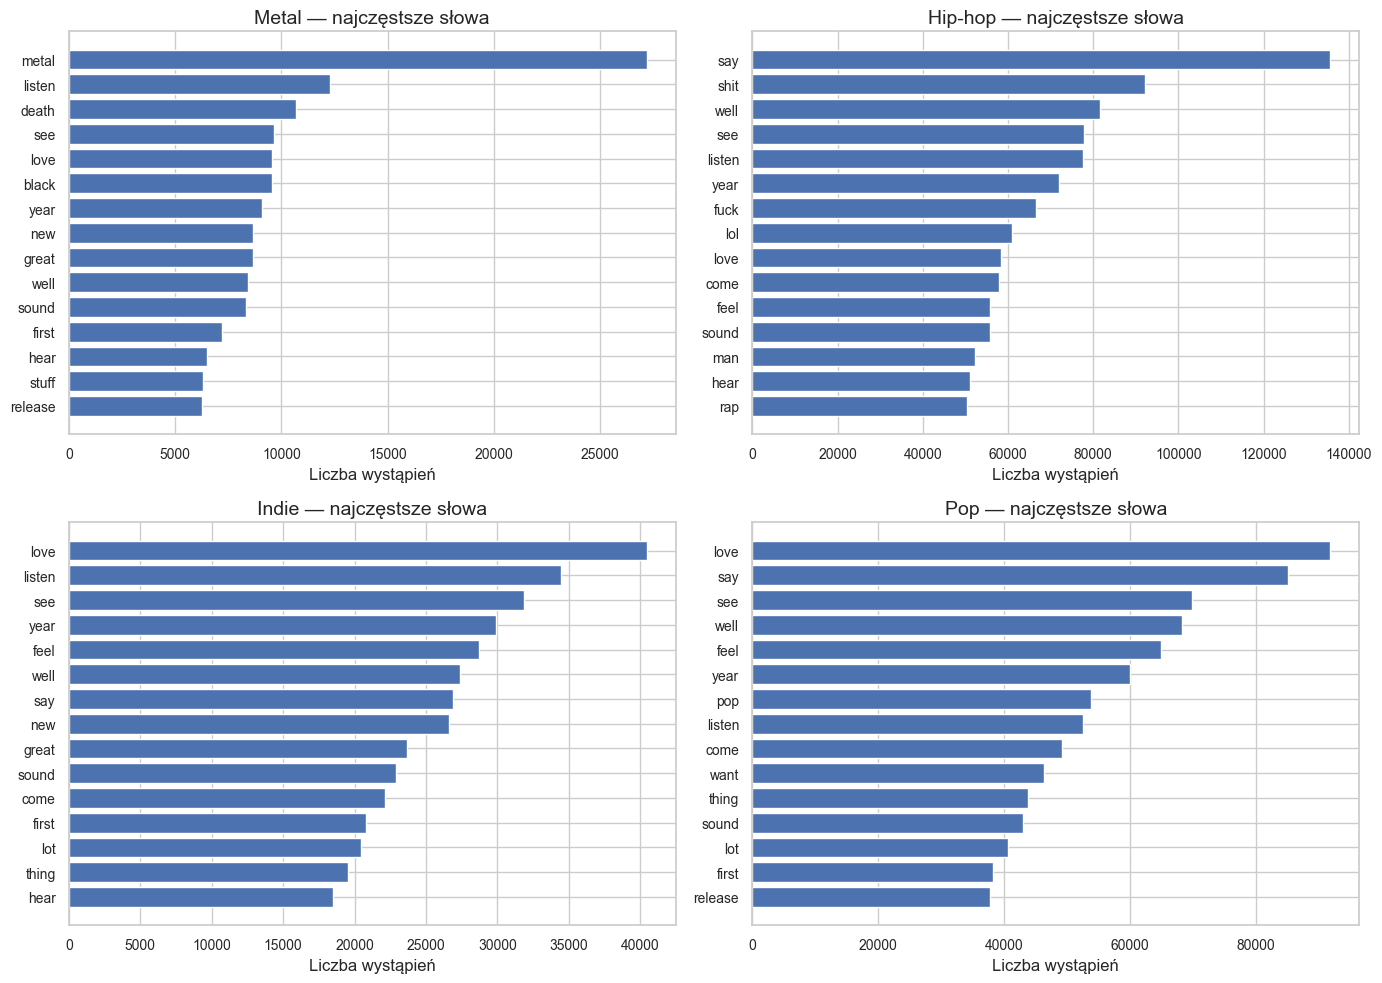

In [14]:
def get_top_items_by_subreddit(df: pd.DataFrame, column: str, top_n: int = 15) -> pd.DataFrame:
    rows = []
    for subreddit, group in df.groupby("subreddit"):
        all_items = []
        for items in group[column]:
            all_items.extend(items)
        for item, count in Counter(all_items).most_common(top_n):
            rows.append({"subreddit": subreddit, "item": item, "count": count})
    return pd.DataFrame(rows)


top_words = get_top_items_by_subreddit(df, "tokens", top_n=15)
top_words.to_csv(REPORTS_DIR / "top_words_by_subreddit.csv", index=False)
display(top_words.head(20))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, top_words.groupby("subreddit")):
    plot_data = group.sort_values("count", ascending=True)
    ax.barh(plot_data["item"], plot_data["count"])
    ax.set_title(f"{subreddit_display(subreddit)} — najczęstsze słowa")
    ax.set_xlabel("Liczba wystąpień")
    ax.set_ylabel("")

for ax in axes[len(top_words["subreddit"].unique()):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

,subreddit,item,count
0,Metal,black metal,4520
1,Metal,death metal,4260
2,Metal,last year,1334
3,Metal,year ago,1097
4,Metal,heavy metal,1079
5,Metal,power metal,981
6,Metal,see live,792
7,Metal,never hear,619
8,Metal,look forward,601
9,Metal,full length,583


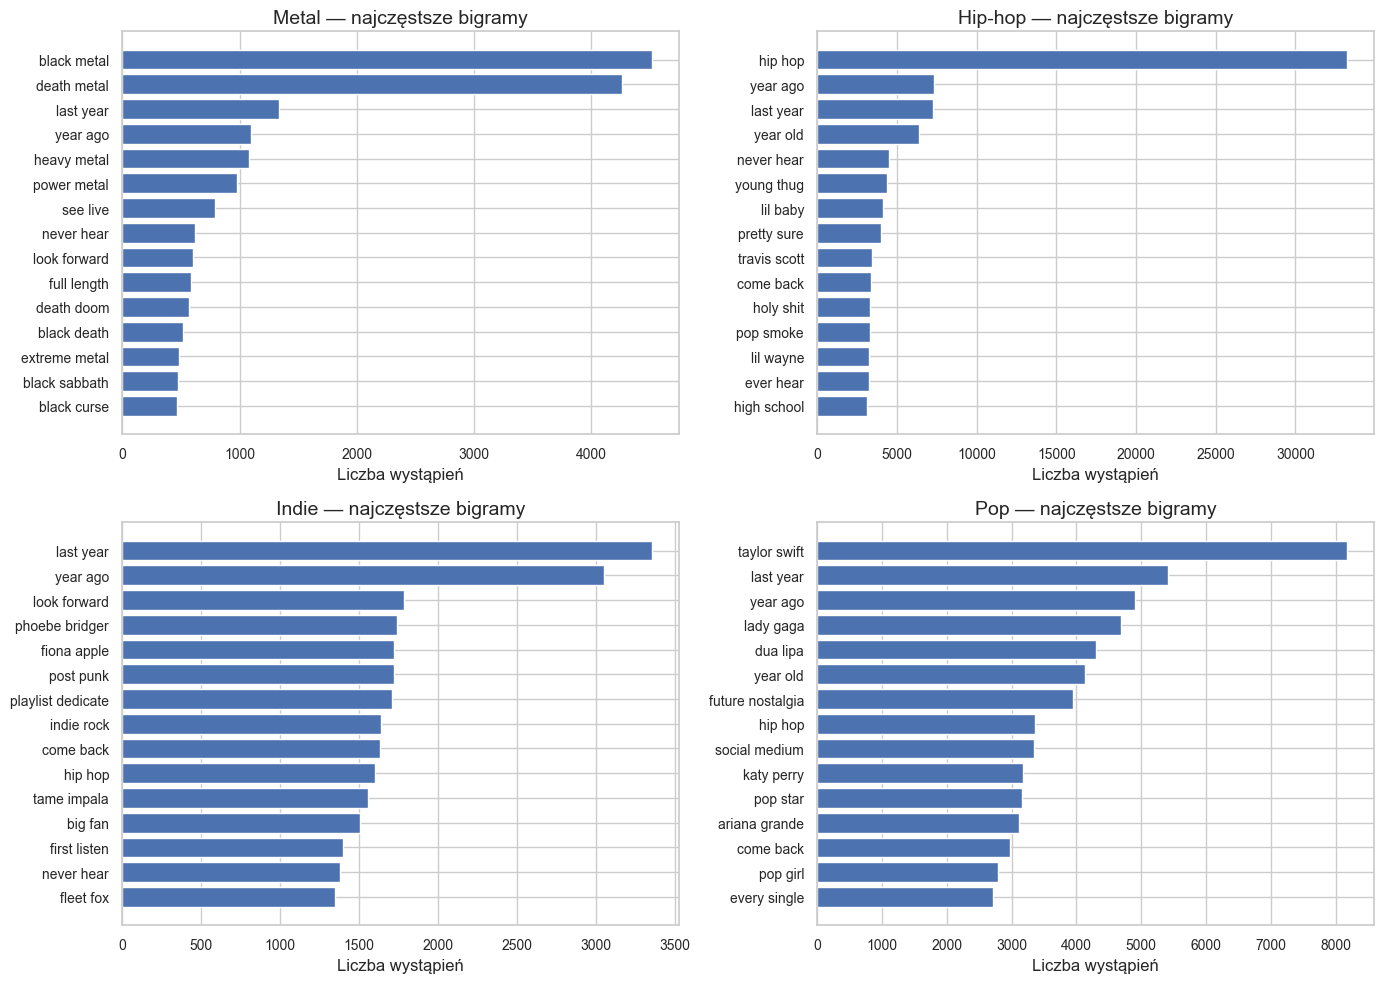

In [15]:
df["bigrams"] = df["tokens"].map(lambda tokens: [" ".join(bg) for bg in ngrams(tokens, 2)])
top_bigrams = get_top_items_by_subreddit(df, "bigrams", top_n=15)
top_bigrams.to_csv(REPORTS_DIR / "top_bigrams_by_subreddit.csv", index=False)
display(top_bigrams.head(20))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, top_bigrams.groupby("subreddit")):
    plot_data = group.sort_values("count", ascending=True)
    ax.barh(plot_data["item"], plot_data["count"])
    ax.set_title(f"{subreddit_display(subreddit)} — najczęstsze bigramy")
    ax.set_xlabel("Liczba wystąpień")
    ax.set_ylabel("")

for ax in axes[len(top_bigrams["subreddit"].unique()):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_top_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretacja najczęstszych słów i bigramów

Najczęstsze słowa pokazują ogólny zakres tematów obecnych w komentarzach, natomiast bigramy pozwalają lepiej uchwycić kontekst wypowiedzi. W analizie społeczności muzycznych szczególnie istotne są powtarzające się nazwy wykonawców, gatunków, wydarzeń, wydań płytowych oraz określenia wartościujące. Różnice między subredditami mogą wskazywać na odmienne style dyskusji: część społeczności może częściej koncentrować się na konkretnych artystach, inne na rekomendacjach, premierach lub ocenach estetycznych.

## 5. Analiza TF-IDF

Sama częstość występowania słów nie zawsze pokazuje, które wyrazy są charakterystyczne dla danej społeczności. Dlatego zastosowano TF-IDF, który podwyższa wagę słów częstych w danym subreddicie, ale relatywnie rzadszych w pozostałych częściach korpusu.

Liczba komentarzy użytych do TF-IDF: 120,000
['subreddit', 'processed_text']


,subreddit,rank,term,tfidf_score
0,Metal,1,metal,0.0361
1,Metal,2,great,0.0188
2,Metal,3,love,0.0186
3,Metal,4,listen,0.0178
4,Metal,5,thank,0.0169
5,Metal,6,death,0.0155
6,Metal,7,see,0.0146
7,Metal,8,new,0.0135
8,Metal,9,black,0.0134
9,Metal,10,well,0.0127


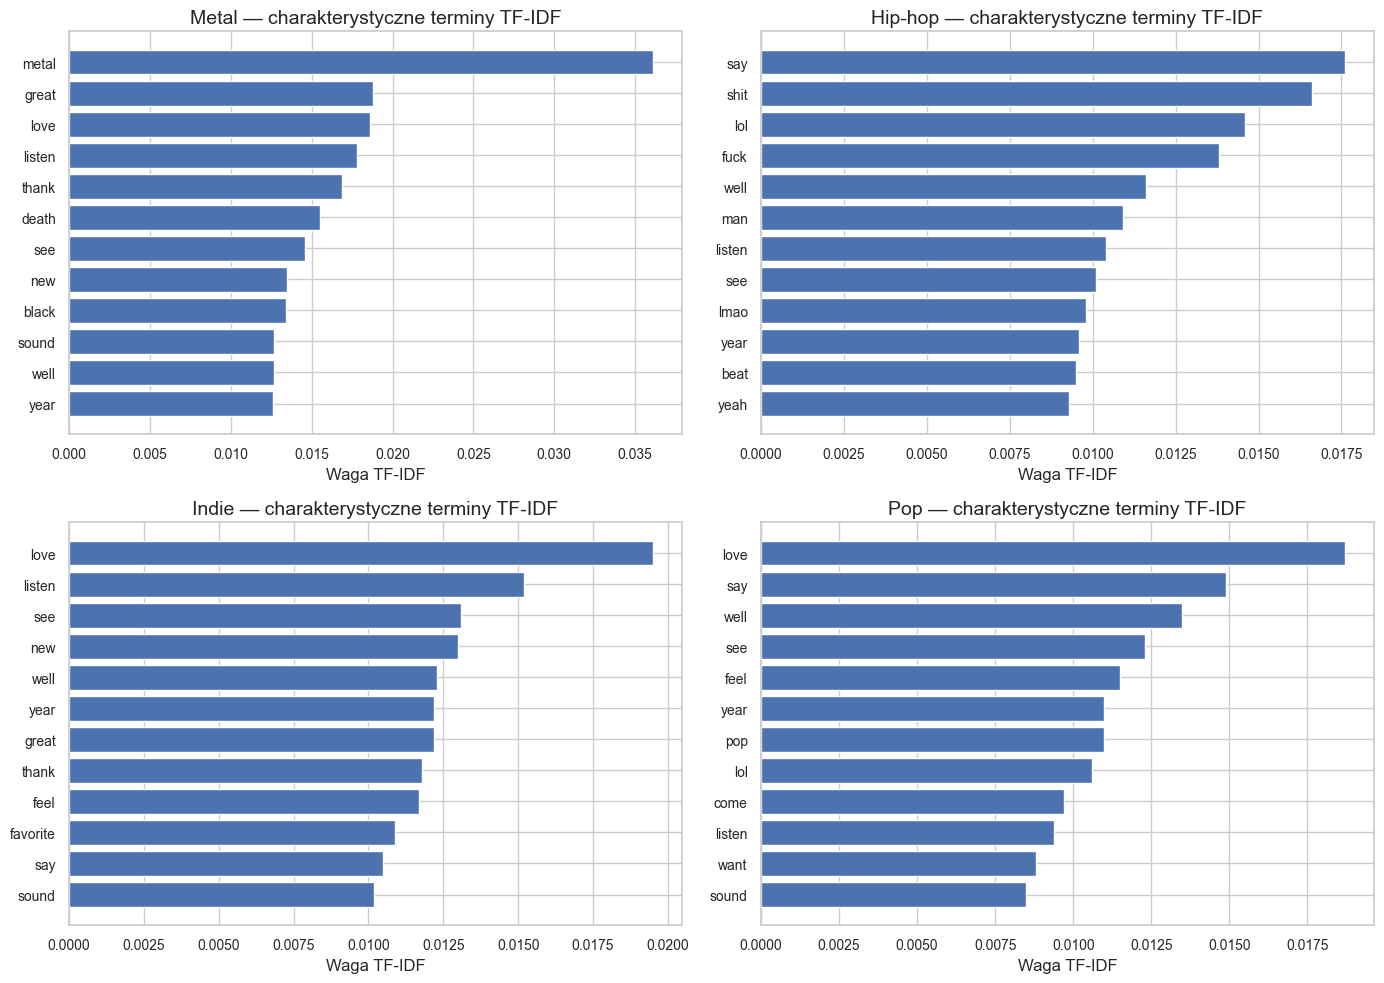

In [20]:
# TF-IDF — charakterystyczne terminy dla subredditów

TFIDF_SAMPLE_PER_SUBREDDIT = 30_000

tfidf_parts = []

for subreddit, group in df[["subreddit", "processed_text"]].dropna().groupby("subreddit"):
    sample = group.sample(
        n=min(len(group), TFIDF_SAMPLE_PER_SUBREDDIT),
        random_state=42
    )
    tfidf_parts.append(sample)

tfidf_df = pd.concat(tfidf_parts, ignore_index=True)

tfidf_df["processed_text"] = tfidf_df["processed_text"].astype(str)

print(f"Liczba komentarzy użytych do TF-IDF: {len(tfidf_df):,}")
print(tfidf_df.columns.tolist())

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

tfidf_matrix = vectorizer.fit_transform(tfidf_df["processed_text"])

feature_names = np.array(vectorizer.get_feature_names_out())

rows = []

for subreddit in sorted(tfidf_df["subreddit"].unique()):
    subreddit_mask = (tfidf_df["subreddit"] == subreddit).to_numpy()

    mean_scores = np.asarray(
        tfidf_matrix[subreddit_mask].mean(axis=0)
    ).ravel()

    top_indices = mean_scores.argsort()[::-1][:20]

    for rank, feature_idx in enumerate(top_indices, start=1):
        rows.append({
            "subreddit": subreddit,
            "rank": rank,
            "term": feature_names[feature_idx],
            "tfidf_score": round(float(mean_scores[feature_idx]), 4),
        })

tfidf_results = pd.DataFrame(rows)

tfidf_results.to_csv(
    REPORTS_DIR / "tfidf_characteristic_terms_by_subreddit.csv",
    index=False
)

display(tfidf_results.head(40))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, tfidf_results.groupby("subreddit")):
    plot_data = group.head(12).sort_values("tfidf_score", ascending=True)

    ax.barh(plot_data["term"], plot_data["tfidf_score"])
    ax.set_title(f"{subreddit_display(subreddit)} — charakterystyczne terminy TF-IDF")
    ax.set_xlabel("Waga TF-IDF")
    ax.set_ylabel("")

for ax in axes[len(tfidf_results["subreddit"].unique()):]:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "text_mining_tfidf_by_subreddit.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretacja TF-IDF

TF-IDF pozwala przejść od ogólnej popularności słów do identyfikacji terminów wyróżniających konkretne społeczności. Jeżeli dany subreddit ma wysokie wartości TF-IDF dla nazw gatunków, artystów albo określonych typów wypowiedzi, można traktować to jako sygnał jego specyficznego profilu tematycznego. W porównaniu z prostą listą najczęstszych słów analiza TF-IDF lepiej pokazuje różnice między fandomami.

## 6. Word clouds

Chmury słów służą jako wizualne podsumowanie słownictwa dominującego w poszczególnych subredditach. Nie zastępują one analizy ilościowej, ale ułatwiają szybkie porównanie profili językowych społeczności.

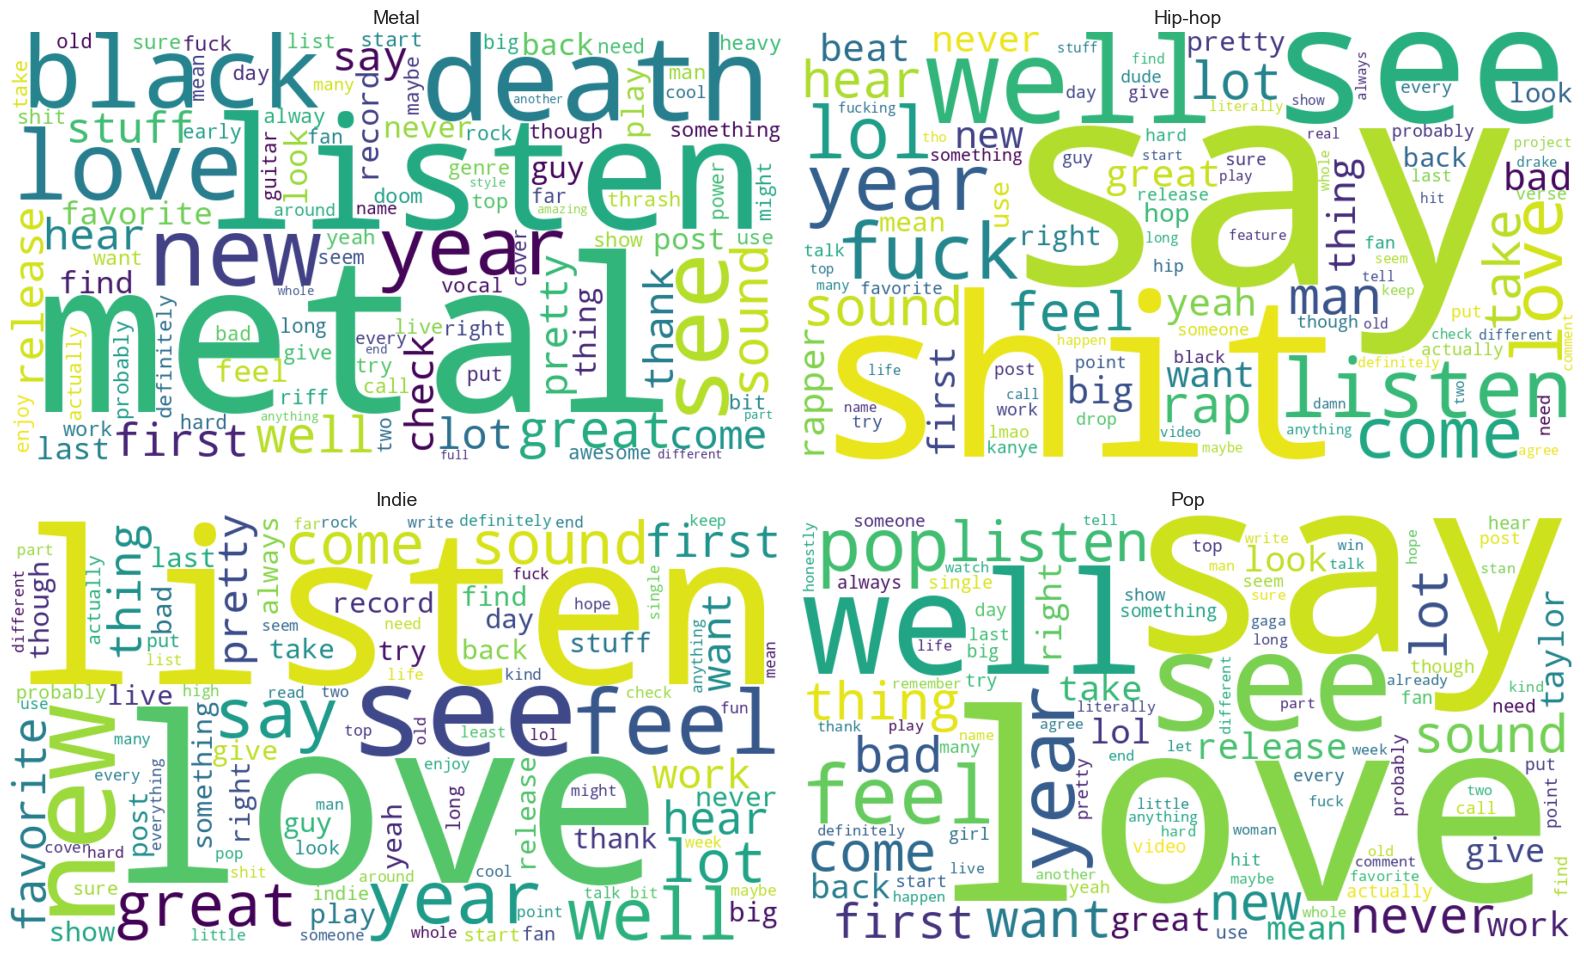

In [22]:
# Chmury słów dla subredditów

WORDCLOUD_SAMPLE_PER_SUBREDDIT = 20_000

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, df.groupby("subreddit")):

    sample = group["processed_text"].dropna().astype(str).sample(
        n=min(len(group), WORDCLOUD_SAMPLE_PER_SUBREDDIT),
        random_state=42
    )

    text = " ".join(sample)

    wordcloud = WordCloud(
        width=900,
        height=500,
        background_color="white",
        max_words=100,
        collocations=False
    ).generate(text)

    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(subreddit_display(subreddit))

for ax in axes[df["subreddit"].nunique():]:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "text_mining_wordclouds.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretacja chmur słów

Chmury słów pokazują ogólny obraz języka używanego w społecznościach, ale należy interpretować je ostrożnie. Wielkość słowa wynika z częstości jego występowania, a nie z jego znaczenia w dyskusji. Dlatego chmury słów najlepiej traktować jako uzupełnienie tabel i wykresów częstości oraz TF-IDF.

## 7. Analiza sentymentu VADER

Do analizy sentymentu wykorzystano VADER, czyli narzędzie przystosowane do krótkich wypowiedzi internetowych. Wynik `compound` przyjmuje wartości od -1 do 1, gdzie wartości ujemne oznaczają wypowiedzi bardziej negatywne, wartości dodatnie bardziej pozytywne, a okolice zera wskazują neutralność.

In [23]:
analyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["body"].map(lambda text: analyzer.polarity_scores(str(text))["compound"])


def classify_sentiment(score: float) -> str:
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"


df["sentiment_label"] = df["sentiment"].map(classify_sentiment)

sentiment_stats = (
    df.groupby("subreddit")["sentiment"]
    .agg(mean="mean", median="median", std="std", min="min", max="max", count="count")
    .round(3)
    .reset_index()
)

sentiment_distribution = (
    df.groupby(["subreddit", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

sentiment_distribution_percent = (
    sentiment_distribution
    .div(sentiment_distribution.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

sentiment_stats.to_csv(REPORTS_DIR / "sentiment_stats_by_subreddit.csv", index=False)
sentiment_distribution_percent.to_csv(REPORTS_DIR / "sentiment_distribution_percent.csv")

display(sentiment_stats)
display(sentiment_distribution_percent)

,subreddit,mean,median,std,min,max,count
0,Metal,0.238,0.340,0.521,-1.0,1.0,105118
1,hiphopheads,0.118,0.000,0.498,-1.0,1.0,1248714
2,indieheads,0.289,0.361,0.492,-1.0,1.0,360403
3,popheads,0.248,0.318,0.514,-1.0,1.0,756336


sentiment_label,negative,neutral,positive
subreddit,,,
Metal,23.7,17.2,59.1
hiphopheads,29.2,23.3,47.6
indieheads,19.6,19.6,60.8
popheads,22.9,18.9,58.3


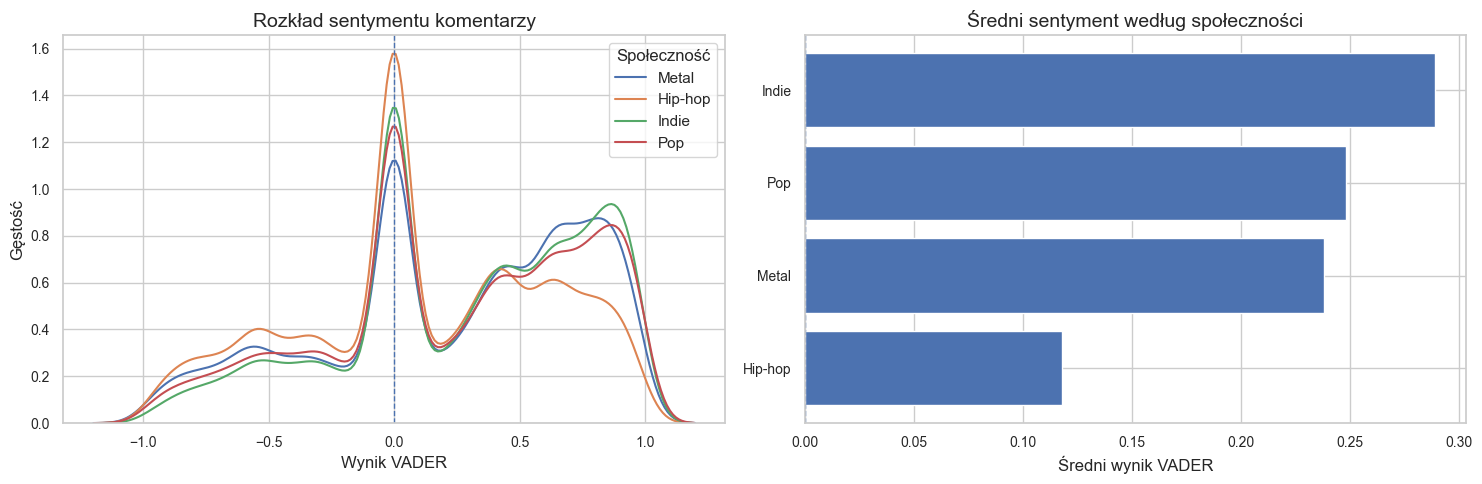

In [25]:
# Podsumowanie sentymentu

SENTIMENT_SAMPLE_PER_SUBREDDIT = 30_000

sentiment_parts = []

for subreddit in sorted(df["subreddit"].dropna().unique()):
    group = df.loc[
        df["subreddit"] == subreddit,
        ["subreddit", "sentiment"]
    ].dropna()

    sample = group.sample(
        n=min(len(group), SENTIMENT_SAMPLE_PER_SUBREDDIT),
        random_state=42
    )

    sentiment_parts.append(sample)

sentiment_plot_df = pd.concat(
    sentiment_parts,
    ignore_index=True
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for subreddit in sorted(sentiment_plot_df["subreddit"].unique()):
    group = sentiment_plot_df.loc[
        sentiment_plot_df["subreddit"] == subreddit
    ]

    sns.kdeplot(
        data=group,
        x="sentiment",
        label=subreddit_display(subreddit),
        ax=axes[0],
        fill=False,
    )

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].set_title("Rozkład sentymentu komentarzy")
axes[0].set_xlabel("Wynik VADER")
axes[0].set_ylabel("Gęstość")
axes[0].legend(title="Społeczność")

means = sentiment_stats.sort_values("mean").copy()

means["subreddit_display"] = (
    means["subreddit"]
    .map(SUBREDDIT_LABELS)
    .fillna(means["subreddit"])
)

axes[1].barh(
    means["subreddit_display"],
    means["mean"]
)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_title("Średni sentyment według społeczności")
axes[1].set_xlabel("Średni wynik VADER")
axes[1].set_ylabel("")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "text_mining_sentiment_summary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

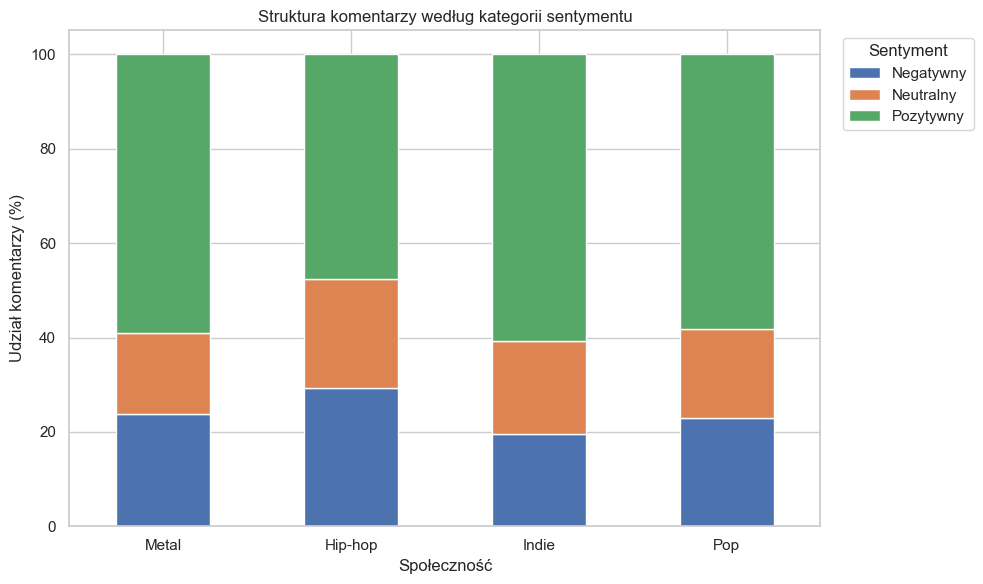

In [ ]:
plot_distribution = sentiment_distribution_percent[
    [col for col in ["negative", "neutral", "positive"] if col in sentiment_distribution_percent.columns]
].copy()

plot_distribution = plot_distribution.rename(
    columns={
        "negative": "Negatywny",
        "neutral": "Neutralny",
        "positive": "Pozytywny"
    }
)

plot_distribution.index = plot_distribution.index.map(subreddit_display)

plot_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
)

plt.title("Struktura komentarzy według kategorii sentymentu")
plt.xlabel("Społeczność")
plt.ylabel("Udział komentarzy (%)")

plt.xticks(rotation=0)

plt.legend(
    title="Sentyment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "text_mining_sentiment_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretacja sentymentu

We wszystkich społecznościach dominowały komentarze pozytywne. Najbardziej pozytywny charakter miały Indie i Metal, natomiast Hip-hop wyróżniał się większym udziałem komentarzy negatywnych i neutralnych. Może to wynikać z częstszych sporów dotyczących artystów i premier oraz ze specyfiki slangu hip-hopowego, który bywa interpretowany jako bardziej negatywny. Pop zajmował pośrednią pozycję i charakteryzował się dużą liczbą emocjonalnych reakcji fanów.

## 8. Modelowanie tematów LDA

Do identyfikacji głównych obszarów tematycznych wykorzystano model LDA. Liczba tematów została ustawiona na 7, ponieważ jest to kompromis między czytelnością interpretacji a możliwością uchwycenia kilku różnych wątków dyskusji. Przy mniejszej liczbie tematów model może nadmiernie łączyć różne obszary, a przy większej liczbie tematów wyniki mogą stać się trudniejsze do ręcznej interpretacji.

Dodatkowo obliczana jest miara coherence, która pomaga ocenić spójność tematów. Wyniki LDA należy jednak traktować jako narzędzie eksploracyjne, a nie jednoznaczny podział treści.

In [14]:
from tqdm import tqdm
import time

NUM_TOPICS = 7
NUM_WORDS = 10
LDA_SAMPLE_PER_SUBREDDIT = 10_000

lda_results = {}
lda_topic_rows = []
coherence_rows = []


def build_lda_for_group(
    tokens_list: list[list[str]],
    num_topics: int = NUM_TOPICS
):
    tokens_list = [
        tokens for tokens in tokens_list
        if isinstance(tokens, list) and len(tokens) >= 5
    ]

    if len(tokens_list) == 0:
        return None, None, None, None, None

    dictionary = corpora.Dictionary(tokens_list)

    dictionary.filter_extremes(
        no_below=10,
        no_above=0.4,
        keep_n=15_000
    )

    corpus = [
        dictionary.doc2bow(tokens)
        for tokens in tokens_list
    ]

    if len(dictionary) == 0 or len(corpus) == 0:
        return None, None, None, None, None

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=3,
        iterations=50,
        chunksize=2000,
        alpha="auto",
        eta="auto",
        per_word_topics=False,
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=tokens_list,
        dictionary=dictionary,
        coherence="c_v",
        processes=1
    )

    coherence = coherence_model.get_coherence()

    return lda_model, corpus, dictionary, tokens_list, coherence


start_time = time.time()

for subreddit, group in tqdm(
    df.groupby("subreddit"),
    desc="LDA by subreddit"
):
    print(f"\nProcessing subreddit: {subreddit}")

    group_for_lda = (
        group[group["tokens"].map(lambda x: isinstance(x, list) and len(x) >= 5)]
        .sample(
            n=min(LDA_SAMPLE_PER_SUBREDDIT, len(group)),
            random_state=42
        )
        .copy()
    )

    print(f"Documents used for LDA: {len(group_for_lda):,}")

    result = build_lda_for_group(
        group_for_lda["tokens"].tolist()
    )

    if result[0] is None:
        print(f"Skipped {subreddit} — not enough valid tokens.")
        continue

    lda_model, corpus, dictionary, tokens_list, coherence = result

    lda_results[subreddit] = {
        "model": lda_model,
        "corpus": corpus,
        "dictionary": dictionary,
        "tokens_list": tokens_list,
        "coherence": coherence,
    }

    coherence_rows.append({
        "subreddit": subreddit,
        "num_topics": NUM_TOPICS,
        "documents_used": len(tokens_list),
        "dictionary_size": len(dictionary),
        "coherence_cv": round(coherence, 3)
    })

    for topic_id in range(NUM_TOPICS):
        top_words_topic = lda_model.show_topic(
            topic_id,
            topn=NUM_WORDS
        )

        lda_topic_rows.append({
            "subreddit": subreddit,
            "topic_id": topic_id + 1,
            "proposed_topic_name": f"Temat {topic_id + 1} — do interpretacji ręcznej",
            "top_words": ", ".join([
                word for word, _ in top_words_topic
            ]),
            "weights": ", ".join([
                str(round(weight, 4))
                for _, weight in top_words_topic
            ])
        })

elapsed = time.time() - start_time
print(f"\nLDA finished in {elapsed / 60:.2f} minutes.")

lda_topics = pd.DataFrame(lda_topic_rows)
lda_coherence = pd.DataFrame(coherence_rows)

lda_topics.to_csv(
    REPORTS_DIR / "lda_topics_by_subreddit.csv",
    index=False
)

lda_coherence.to_csv(
    REPORTS_DIR / "lda_coherence_by_subreddit.csv",
    index=False
)

display(lda_coherence)
display(lda_topics)

LDA by subreddit:   0%|          | 0/4 [00:00<?, ?it/s]


Processing subreddit: Metal
Documents used for LDA: 10,000


LDA by subreddit:  25%|██▌       | 1/4 [00:07<00:22,  7.34s/it]


Processing subreddit: hiphopheads
Documents used for LDA: 10,000


LDA by subreddit:  50%|█████     | 2/4 [00:13<00:13,  6.83s/it]

...


Processing subreddit: popheads
Documents used for LDA: 10,000


LDA by subreddit: 100%|██████████| 4/4 [00:28<00:00,  7.05s/it]


LDA finished in 0.47 minutes.


,subreddit,num_topics,documents_used,dictionary_size,coherence_cv
0,Metal,7,10000,2561,0.506
1,hiphopheads,7,10000,2159,0.544
2,indieheads,7,10000,2466,0.532
3,popheads,7,10000,2575,0.477


,subreddit,topic_id,proposed_topic_name,top_words,weights
0,Metal,1,Temat 1 — do interpretacji ręcznej,"death, blood, sound, black, riff, love, well, ...","0.0111, 0.0082, 0.008, 0.0076, 0.0071, 0.0069,..."
1,Metal,2,Temat 2 — do interpretacji ręcznej,"run, year, favorite, see, shit, video, holy, l...","0.0168, 0.0164, 0.0138, 0.0122, 0.0104, 0.0103..."
2,Metal,3,Temat 3 — do interpretacji ręcznej,"see, love, great, first, listen, live, hear, g...","0.0233, 0.0181, 0.0155, 0.0145, 0.0116, 0.0112..."
3,Metal,4,Temat 4 — do interpretacji ręcznej,"metal, sound, look, new, death, name, well, fi...","0.0317, 0.0207, 0.012, 0.0113, 0.0109, 0.0098,..."
4,Metal,5,Temat 5 — do interpretacji ręcznej,"metal, well, death, doom, post, say, listen, s...","0.0122, 0.0122, 0.0119, 0.0115, 0.0098, 0.009,..."
5,Metal,6,Temat 6 — do interpretacji ręcznej,"metal, black, death, new, check, release, list...","0.0825, 0.0361, 0.0179, 0.0128, 0.011, 0.0108,..."
6,Metal,7,Temat 7 — do interpretacji ręcznej,"listen, year, feel, come, lot, find, hear, pre...","0.0221, 0.0109, 0.0088, 0.0087, 0.0085, 0.0082..."
7,hiphopheads,1,Temat 1 — do interpretacji ręcznej,"listen, hear, lot, first, feel, sound, find, g...","0.0218, 0.0122, 0.0116, 0.0103, 0.0098, 0.0087..."
8,hiphopheads,2,Temat 2 — do interpretacji ręcznej,"big, well, pretty, sample, fan, feel, somethin...","0.018, 0.0147, 0.0075, 0.0075, 0.0072, 0.0062,..."
9,hiphopheads,3,Temat 3 — do interpretacji ręcznej,"year, day, never, kanye, pretty, feel, release...","0.0104, 0.0097, 0.0088, 0.0081, 0.0079, 0.0074..."


In [15]:
# Save LDA results checkpoint

import pickle
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
lda_checkpoint_path = CHECKPOINT_DIR / "lda_results_checkpoint.pkl"
with open(lda_checkpoint_path, "wb") as handle:
    pickle.dump({
        "lda_results": lda_results,
        "lda_topics": lda_topics,
        "lda_coherence": lda_coherence,
    }, handle)
print(f"Zapisano wyniki LDA do: {lda_checkpoint_path}")
print(f"Liczba subredditów w lda_results: {len(lda_results)}")
print(f"lda_topics shape: {lda_topics.shape}")
print(f"lda_coherence shape: {lda_coherence.shape}")

Zapisano wyniki LDA do: ..\data\checkpoints\lda_results_checkpoint.pkl
Liczba subredditów w lda_results: 4
lda_topics shape: (28, 5)
lda_coherence shape: (4, 5)


In [16]:
# Load LDA checkpoint

import pickle

lda_checkpoint_path = CHECKPOINT_DIR / "lda_results_checkpoint.pkl"

print("Loading LDA checkpoint...")

with open(lda_checkpoint_path, "rb") as handle:
    checkpoint = pickle.load(handle)

lda_results = checkpoint["lda_results"]
lda_topics = checkpoint["lda_topics"]
lda_coherence = checkpoint["lda_coherence"]

print("LDA checkpoint loaded successfully.")

print(f"Liczba subredditów: {len(lda_results)}")

display(lda_coherence)
display(lda_topics.head())

Loading LDA checkpoint...
LDA checkpoint loaded successfully.
Liczba subredditów: 4


,subreddit,num_topics,documents_used,dictionary_size,coherence_cv
0,Metal,7,10000,2561,0.506
1,hiphopheads,7,10000,2159,0.544
2,indieheads,7,10000,2466,0.532
3,popheads,7,10000,2575,0.477


,subreddit,topic_id,proposed_topic_name,top_words,weights
0,Metal,1,Temat 1 — do interpretacji ręcznej,"death, blood, sound, black, riff, love, well, ...","0.0111, 0.0082, 0.008, 0.0076, 0.0071, 0.0069,..."
1,Metal,2,Temat 2 — do interpretacji ręcznej,"run, year, favorite, see, shit, video, holy, l...","0.0168, 0.0164, 0.0138, 0.0122, 0.0104, 0.0103..."
2,Metal,3,Temat 3 — do interpretacji ręcznej,"see, love, great, first, listen, live, hear, g...","0.0233, 0.0181, 0.0155, 0.0145, 0.0116, 0.0112..."
3,Metal,4,Temat 4 — do interpretacji ręcznej,"metal, sound, look, new, death, name, well, fi...","0.0317, 0.0207, 0.012, 0.0113, 0.0109, 0.0098,..."
4,Metal,5,Temat 5 — do interpretacji ręcznej,"metal, well, death, doom, post, say, listen, s...","0.0122, 0.0122, 0.0119, 0.0115, 0.0098, 0.009,..."


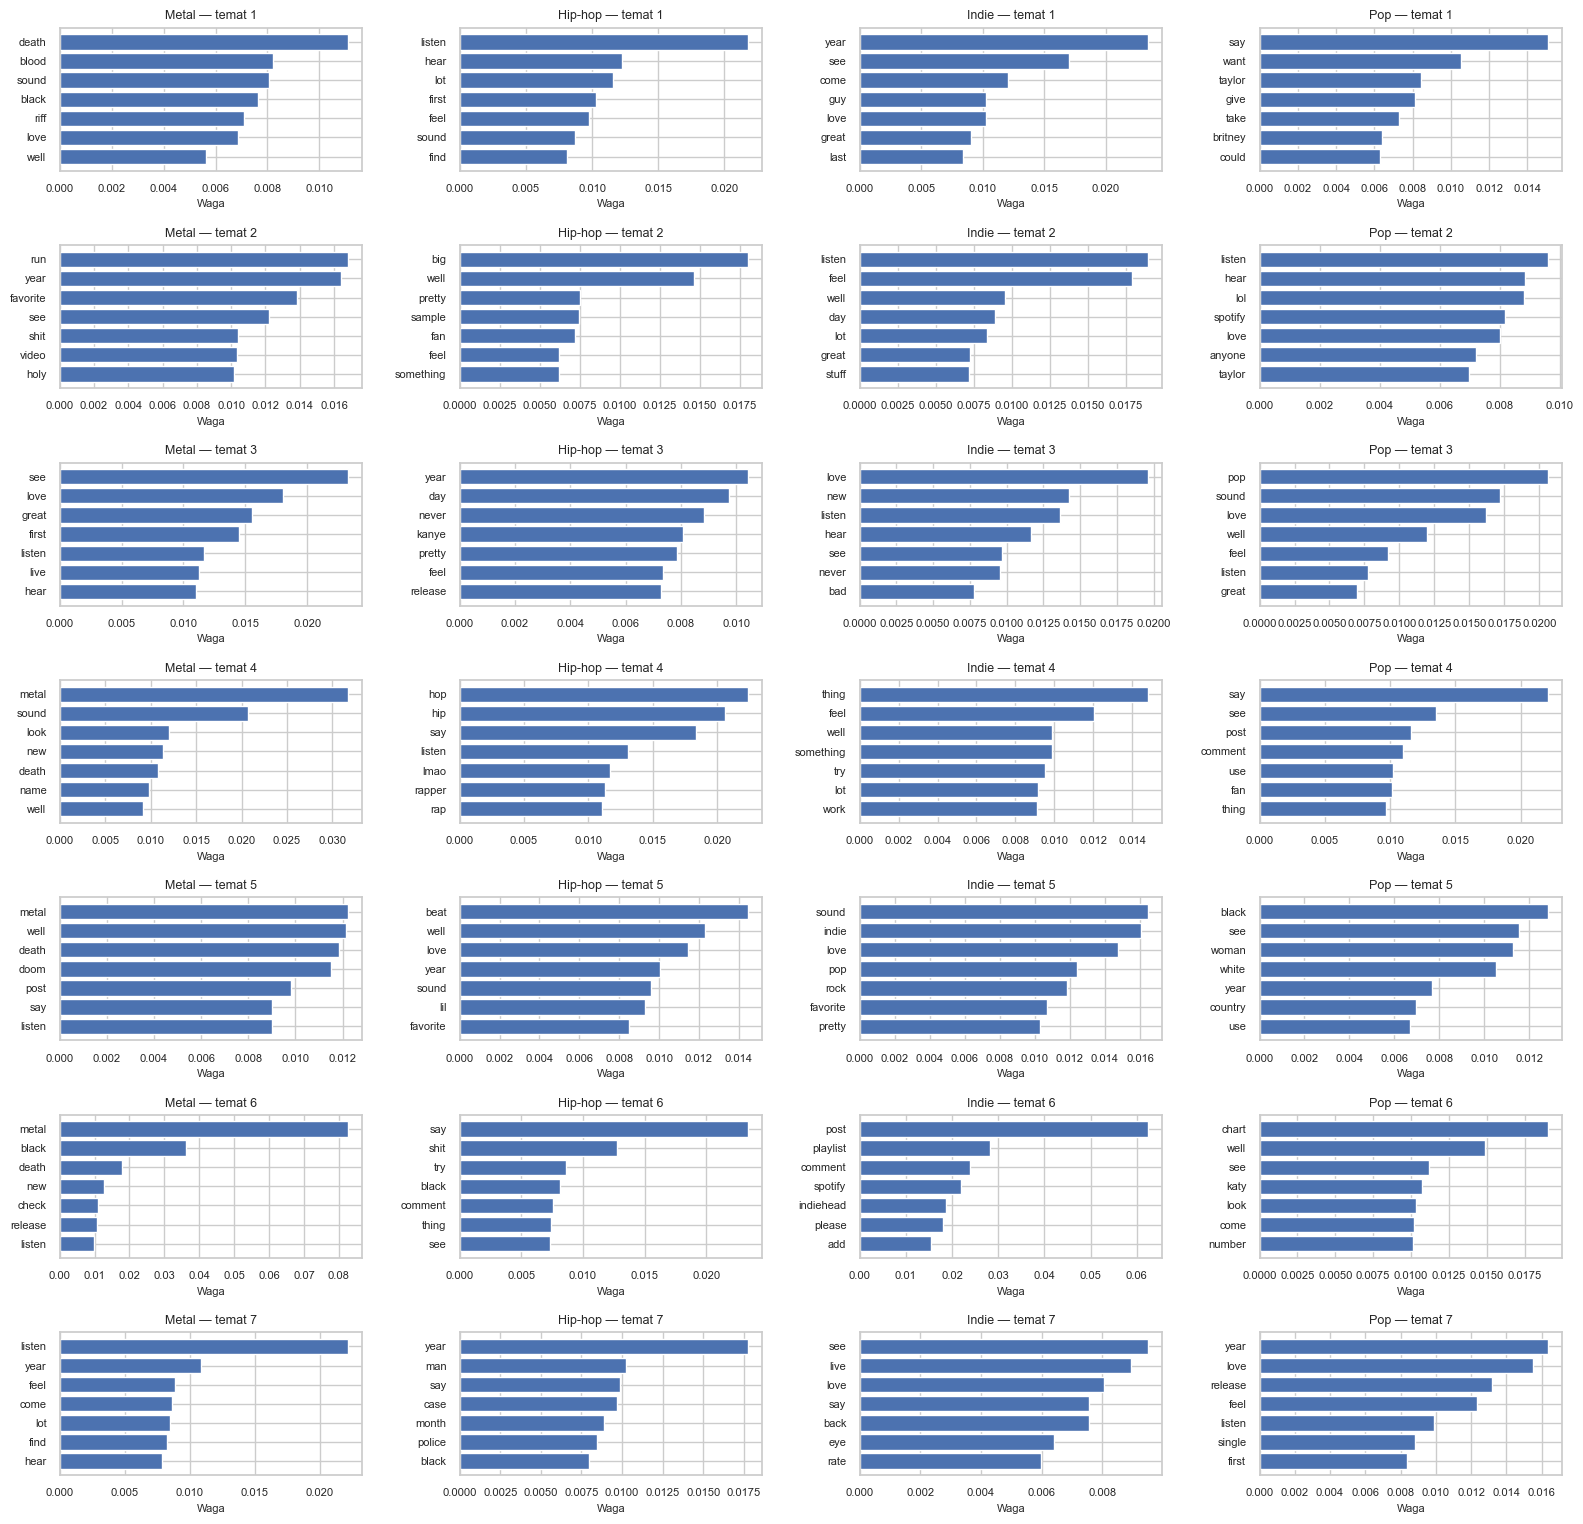

In [18]:
if lda_results:

    fig, axes = plt.subplots(
        NUM_TOPICS,
        len(lda_results),
        figsize=(4 * len(lda_results), 2.2 * NUM_TOPICS)
    )

    if len(lda_results) == 1:
        axes = np.array(axes).reshape(NUM_TOPICS, 1)

    for col, (subreddit, result) in enumerate(lda_results.items()):

        lda_model = result["model"]

        for topic_id in range(NUM_TOPICS):

            ax = axes[topic_id, col]

            top = lda_model.show_topic(topic_id, topn=7)

            words = [word for word, _ in top][::-1]
            weights = [weight for _, weight in top][::-1]

            ax.barh(words, weights)

            ax.set_title(
                f"{subreddit_display(subreddit)} — temat {topic_id + 1}",
                fontsize=9
            )

            ax.set_xlabel("Waga", fontsize=8)

            ax.tick_params(labelsize=8)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / "text_mining_lda_topics.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

,subreddit,topic_id,comment_count,share_percent
0,Metal,1,1183,11.8
1,Metal,2,528,5.3
2,Metal,3,2484,24.8
3,Metal,4,1217,12.2
4,Metal,5,1201,12.0
5,Metal,6,1522,15.2
6,Metal,7,1865,18.6
7,hiphopheads,1,1353,13.5
8,hiphopheads,2,854,8.5
9,hiphopheads,3,955,9.6


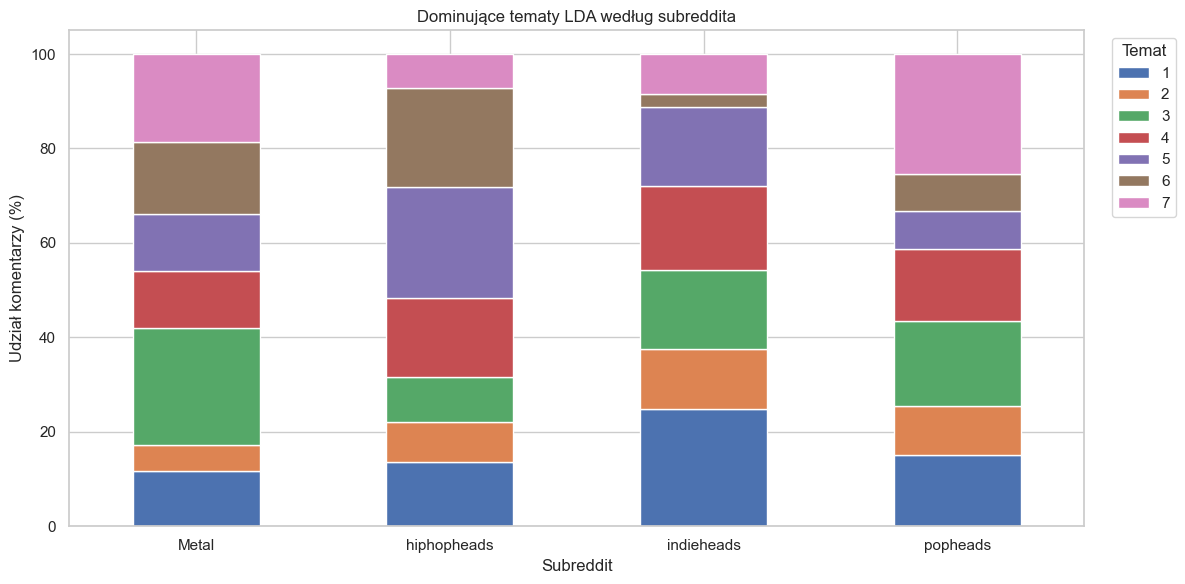

In [19]:
dominant_topic_rows = []

for subreddit, result in lda_results.items():
    lda_model = result["model"]
    corpus = result["corpus"]

    topic_counts = Counter()
    for bow in corpus:
        topic_distribution = lda_model.get_document_topics(bow)
        if topic_distribution:
            dominant_topic = max(topic_distribution, key=lambda item: item[1])[0] + 1
            topic_counts[dominant_topic] += 1

    total_docs = sum(topic_counts.values())
    for topic_id in range(1, NUM_TOPICS + 1):
        count = topic_counts.get(topic_id, 0)
        dominant_topic_rows.append({
            "subreddit": subreddit,
            "topic_id": topic_id,
            "comment_count": count,
            "share_percent": round((count / total_docs) * 100, 1) if total_docs else 0
        })

dominant_topics = pd.DataFrame(dominant_topic_rows)
dominant_topics.to_csv(REPORTS_DIR / "lda_dominant_topics_by_subreddit.csv", index=False)
display(dominant_topics)

if not dominant_topics.empty:
    pivot = dominant_topics.pivot(index="subreddit", columns="topic_id", values="share_percent")
    pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title("Dominujące tematy LDA według subreddita")
    plt.xlabel("Subreddit")
    plt.ylabel("Udział komentarzy (%)")
    plt.xticks(rotation=0)
    plt.legend(title="Temat", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "text_mining_lda_dominant_topics.png", dpi=150, bbox_inches="tight")
    plt.show()

In [21]:
# Ręczna interpretacja tematów LDA

lda_topic_interpretation = pd.DataFrame([
    
    # METAL
    ["Metal", 1, "Ekstremalne odmiany metalu i ciężkie brzmienia"],
    ["Metal", 2, "Codzienne dyskusje i reakcje użytkowników"],
    ["Metal", 3, "Odsłuch muzyki i emocje związane z utworami"],
    ["Metal", 4, "Nowe albumy i klasyczne elementy metalu"],
    ["Metal", 5, "Podgatunki metalu i stylistyka"],
    ["Metal", 6, "Premiery i rekomendacje albumów"],
    ["Metal", 7, "Opinie użytkowników i pierwsze wrażenia"],

    # HIP-HOP
    ["Hip-hop", 1, "Odsłuch utworów i reakcje emocjonalne"],
    ["Hip-hop", 2, "Luźne rozmowy i komentarze społeczności"],
    ["Hip-hop", 3, "Premiery albumów i popularni artyści"],
    ["Hip-hop", 4, "Kultura rapowa i wykonawcy"],
    ["Hip-hop", 5, "Ocena beatów i jakości utworów"],
    ["Hip-hop", 6, "Komentarze i dyskusje społeczności"],
    ["Hip-hop", 7, "Dyskusje społeczne i bieżące wydarzenia"],

    # INDIE
    ["Indie", 1, "Ocena utworów i pozytywne reakcje"],
    ["Indie", 2, "Codzienne rozmowy o muzyce"],
    ["Indie", 3, "Emocjonalny odbiór muzyki"],
    ["Indie", 4, "Luźne komentarze i opinie użytkowników"],
    ["Indie", 5, "Gatunki alternatywne i gust muzyczny"],
    ["Indie", 6, "Playlisty i rekomendacje Spotify"],
    ["Indie", 7, "Subiektywne opinie i oceny utworów"],

    # POP
    ["Pop", 1, "Popularni artyści popowi i fandom"],
    ["Pop", 2, "Streaming i słuchanie muzyki"],
    ["Pop", 3, "Mainstreamowy pop i odbiór utworów"],
    ["Pop", 4, "Komentowanie postów i aktywność społeczności"],
    ["Pop", 5, "Wizerunek artystów i kultura popularna"],
    ["Pop", 6, "Listy przebojów i popularność utworów"],
    ["Pop", 7, "Premiery singli i reakcje fanów"],

], columns=[
    "społeczność",
    "temat",
    "interpretacja"
])

lda_topic_interpretation.to_csv(
    REPORTS_DIR / "lda_topic_interpretation.csv",
    index=False
)

display(lda_topic_interpretation)

,społeczność,temat,interpretacja
0,Metal,1,Ekstremalne odmiany metalu i ciężkie brzmienia
1,Metal,2,Codzienne dyskusje i reakcje użytkowników
2,Metal,3,Odsłuch muzyki i emocje związane z utworami
3,Metal,4,Nowe albumy i klasyczne elementy metalu
4,Metal,5,Podgatunki metalu i stylistyka
5,Metal,6,Premiery i rekomendacje albumów
6,Metal,7,Opinie użytkowników i pierwsze wrażenia
7,Hip-hop,1,Odsłuch utworów i reakcje emocjonalne
8,Hip-hop,2,Luźne rozmowy i komentarze społeczności
9,Hip-hop,3,Premiery albumów i popularni artyści


## Interpretacja tematów LDA

Tematy wygenerowane przez model LDA zostały poddane ręcznej interpretacji na podstawie najważniejszych słów przypisanych do każdego tematu oraz udziału tematów w poszczególnych społecznościach. Analiza pokazała, że różnice między subredditami były widoczne nie tylko w słownictwie, ale również w strukturze dominujących dyskusji.

W społeczności Hip-hop częściej pojawiały się odniesienia do konkretnych artystów, premier albumów oraz szeroko rozumianej kultury rapowej. Dominowały tematy związane z oceną utworów, beatów, premier i aktywnością społeczności. Może to wynikać z bardzo dynamicznego charakteru środowiska hip-hopowego, w którym regularnie pojawiają się nowe wydawnictwa i intensywne dyskusje wokół artystów oraz bieżących wydarzeń.

Pop koncentrował się głównie wokół popularnych wykonawców, list przebojów oraz reakcji fanów. Największy udział miały tematy związane z premierami singli, fandomami i kulturą popularną. Wyniki mogą sugerować, że społeczność ta jest silnie skoncentrowana wokół aktualnych trendów muzycznych oraz medialnej aktywności artystów.

Indie zawierało więcej tematów związanych z rekomendacjami muzycznymi, playlistami oraz emocjonalnym odbiorem utworów. Najbardziej widoczne były tematy dotyczące ocen muzyki, codziennych rekomendacji oraz wymiany opinii pomiędzy użytkownikami. Może to wskazywać na bardziej „odkrywczy” charakter społeczności, skoncentrowany wokół poszukiwania nowej muzyki i dzielenia się mniej mainstreamowymi wykonawcami.

Metal skupiał się przede wszystkim na podgatunkach oraz cięższych odmianach muzyki. Dominowały tematy związane z odsłuchem muzyki, emocjami oraz oceną konkretnych albumów i brzmień. Wyniki sugerują, że użytkownicy tej społeczności częściej koncentrowali się na technicznych i stylistycznych aspektach muzyki oraz bardziej szczegółowych dyskusjach dotyczących gatunku.

Widoczna była również różnica w rozkładzie tematów pomiędzy społecznościami. Indie oraz Pop miały bardziej równomierny udział wielu tematów, natomiast w Metal i Hip-hop kilka tematów dominowało wyraźniej nad pozostałymi. Może to sugerować większą koncentrację dyskusji wokół określonych obszarów zainteresowań w tych społecznościach.

Niektóre tematy miały bardziej ogólny charakter i zawierały słowa typowe dla codziennych dyskusji internetowych, dlatego interpretowano przede wszystkim najbardziej spójne i wyraźne grupy słów.

## 9. Ograniczenia analizy

Analiza text mining ma kilka istotnych ograniczeń:

- VADER dobrze sprawdza się w krótkich tekstach internetowych, ale może słabiej rozpoznawać ironię, sarkazm i kontekst kulturowy.
- Język Reddita zawiera slang, skróty, memy, nazwy własne i odniesienia środowiskowe, które nie zawsze są poprawnie interpretowane przez standardowe narzędzia NLP.
- LDA traktuje dokumenty jako zbiory słów i nie rozumie kolejności zdań ani głębszego kontekstu wypowiedzi.
- Wyniki TF-IDF zależą od zakresu korpusu oraz zastosowanej listy stopwords.
- Ręczne nazwanie tematów LDA ma charakter interpretacyjny i może zależeć od wiedzy badacza o danej społeczności muzycznej.
- Komentarze z Reddita nie muszą reprezentować całej społeczności fanów danego gatunku muzycznego, lecz aktywnych użytkowników konkretnej platformy.

## 10. Wnioski z analizy text mining

Analiza text mining pokazała wyraźne różnice językowe pomiędzy badanymi społecznościami muzycznymi. Każdy subreddit charakteryzował się własnym słownictwem, tematami dyskusji oraz profilem sentymentu, co potwierdza odmienny charakter analizowanych społeczności.

Analiza TF-IDF wskazała, że Hip-hop koncentrował się głównie wokół artystów, premier i kultury rapowej. W Pop często pojawiały się odniesienia do popularnych wykonawców, fandomów oraz bieżących wydarzeń muzycznych. Indie wyróżniało się większą liczbą rekomendacji muzycznych i rozmów o odkrywaniu nowej muzyki, natomiast Metal częściej skupiał się na podgatunkach oraz ocenie brzmienia i albumów.

Analiza sentymentu pokazała, że we wszystkich społecznościach dominowały komentarze pozytywne. Najbardziej pozytywny charakter miały Indie i Metal, podczas gdy Hip-hop wyróżniał się większym udziałem komentarzy negatywnych i neutralnych. Może to wynikać zarówno z bardziej konfrontacyjnego stylu dyskusji, jak i specyfiki slangu hip-hopowego.

Modelowanie tematów LDA potwierdziło różnice między społecznościami. W Hip-hopie dominowały tematy związane z premierami, oceną utworów i aktywnością społeczności. Pop koncentrował się wokół artystów oraz reakcji fanów, Indie wokół rekomendacji i emocjonalnego odbioru muzyki, a Metal wokół dyskusji o brzmieniu i gatunkach muzycznych.

Całościowo analiza text mining pokazała, że społeczności różniły się nie tylko skalą aktywności, ale również sposobem komunikacji, dominującymi tematami oraz charakterem emocjonalnym dyskusji.


## Reset środowiska po restarcie kernela

In [13]:
# =========================================================
# PRZYWRÓCENIE ŚRODOWISKA PO RESECIE KERNELA — NOTEBOOK 2
# =========================================================

import re
import time
import pickle
import warnings

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

warnings.filterwarnings("ignore")

# =========================================================
# Ścieżki
# =========================================================

BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"
CHECKPOINT_DIR = DATA_DIR / "checkpoints"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "processed" / "all_subreddits_clean.csv"

RAW_CHECKPOINT = CHECKPOINT_DIR / "df_raw_checkpoint.pkl"
PREPROCESSED_PICKLE_CHECKPOINT = CHECKPOINT_DIR / "df_preprocessed_checkpoint.pkl"
PREPROCESSED_LIGHT_CHECKPOINT = CHECKPOINT_DIR / "df_preprocessed_light.csv"
LDA_RESULTS_CHECKPOINT = CHECKPOINT_DIR / "lda_results_checkpoint.pkl"

# =========================================================
# Ustawienia notebooka
# =========================================================

NUM_TOPICS = 7
NUM_WORDS = 10

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# =========================================================
# Funkcja pomocnicza do nazw społeczności na wykresach
# =========================================================

SUBREDDIT_LABELS = {
    "Metal": "Metal",
    "metal": "Metal",
    "hiphopheads": "Hip-hop",
    "HipHopHeads": "Hip-hop",
    "popheads": "Pop",
    "Popheads": "Pop",
    "indieheads": "Indie",
    "Indieheads": "Indie",
}

def subreddit_display(subreddit):
    return SUBREDDIT_LABELS.get(str(subreddit), str(subreddit).replace("r/", ""))

# =========================================================
# Konfiguracja NLP
# =========================================================

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

base_stopwords = set(stopwords.words("english"))

extra_stopwords = {
    "like", "just", "get", "got", "one", "know",
    "think", "really", "would", "also", "even",
    "much", "still", "way", "good", "make",
    "people", "time", "music", "song", "songs",
    "album", "albums", "artist", "artists",
    "track", "tracks", "band", "bands",
    "https", "http", "www", "com",
    "reddit", "amp", "subreddit"
}

STOP_WORDS = base_stopwords | extra_stopwords
stemmer = PorterStemmer()

# =========================================================
# spaCy
# =========================================================

USE_SPACY = False
nlp = None

try:
    import spacy

    nlp = spacy.load(
        "en_core_web_sm",
        disable=["parser", "ner"]
    )

    USE_SPACY = True

except Exception as error:
    USE_SPACY = False
    nlp = None
    print(f"spaCy nie zostało wczytane: {error}")

# =========================================================
# Wczytywanie checkpointów
# =========================================================

df_raw = None
df = None

lda_results = {}
lda_topics = None
lda_coherence = None

# df_raw

if RAW_CHECKPOINT.exists():
    print("Wczytywanie df_raw z checkpointu...")

    df_raw = pd.read_pickle(RAW_CHECKPOINT)

    print(f"Wczytano df_raw: {df_raw.shape}")

elif DATA_PATH.exists():
    print("Brak checkpointu df_raw. Wczytywanie danych z CSV...")

    df_raw = pd.read_csv(DATA_PATH)

    print(f"Wczytano df_raw z CSV: {df_raw.shape}")

else:
    print(f"Nie znaleziono danych wejściowych: {DATA_PATH}")

# df po przygotowaniu tekstu

if PREPROCESSED_LIGHT_CHECKPOINT.exists():
    print("Wczytywanie lekkiego checkpointu df...")

    df = pd.read_csv(PREPROCESSED_LIGHT_CHECKPOINT)

    if "tokens" not in df.columns and "processed_text" in df.columns:
        df["tokens"] = (
            df["processed_text"]
            .fillna("")
            .astype(str)
            .str.split()
        )

    print(f"Wczytano df z lekkiego checkpointu: {df.shape}")
    print("Kolumny:")
    print(df.columns.tolist())

elif PREPROCESSED_PICKLE_CHECKPOINT.exists():
    print("Wczytywanie pełnego checkpointu df...")

    df = pd.read_pickle(PREPROCESSED_PICKLE_CHECKPOINT)

    print(f"Wczytano df z pełnego checkpointu: {df.shape}")
    print("Kolumny:")
    print(df.columns.tolist())

else:
    print("Nie znaleziono checkpointu danych po przygotowaniu tekstu.")

# LDA

if LDA_RESULTS_CHECKPOINT.exists():
    print("Wczytywanie checkpointu LDA...")

    with open(LDA_RESULTS_CHECKPOINT, "rb") as handle:
        checkpoint = pickle.load(handle)

    lda_results = checkpoint.get("lda_results", {})
    lda_topics = checkpoint.get("lda_topics")
    lda_coherence = checkpoint.get("lda_coherence")

    print(f"Wczytano LDA. Liczba społeczności: {len(lda_results)}")

    if hasattr(lda_topics, "shape"):
        print(f"lda_topics shape: {lda_topics.shape}")

    if hasattr(lda_coherence, "shape"):
        print(f"lda_coherence shape: {lda_coherence.shape}")

else:
    print("Nie znaleziono checkpointu LDA.")

# =========================================================
# Status końcowy
# =========================================================

print("\n=========================")
print("Środowisko notebooka 2 zostało przywrócone.")
print("=========================")

print(f"spaCy enabled: {USE_SPACY}")
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")
print(f"CHECKPOINT_DIR: {CHECKPOINT_DIR}")

if df_raw is not None:
    print(f"df_raw: {df_raw.shape}")

if df is not None:
    print(f"df: {df.shape}")

if lda_results:
    print(f"lda_results: {len(lda_results)} społeczności")

Wczytywanie df_raw z checkpointu...
Wczytano df_raw: (2492764, 15)
Wczytywanie lekkiego checkpointu df...
Wczytano df z lekkiego checkpointu: (2470571, 10)
Kolumny:
['comment_id', 'author', 'subreddit', 'body', 'clean_text', 'processed_text', 'token_count', 'score', 'created_utc', 'tokens']
Wczytywanie checkpointu LDA...
Wczytano LDA. Liczba społeczności: 4
lda_topics shape: (28, 5)
lda_coherence shape: (4, 5)

Środowisko notebooka 2 zostało przywrócone.
spaCy enabled: True
FIGURES_DIR: ..\outputs\figures
REPORTS_DIR: ..\outputs\reports
CHECKPOINT_DIR: ..\data\checkpoints
df_raw: (2492764, 15)
df: (2470571, 10)
lda_results: 4 społeczności
